
# Laboratorio 2 - Roberto Farfán

Cada problema incluye la imagen original, la función solicitada y el resultado obtenido.

In [1]:
# Librerías utilizadas en todo el notebook
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12

def cargar_imagen(ruta, modo=cv2.IMREAD_COLOR):
    """Carga una imagen y valida que exista."""
    imagen = cv2.imread(ruta, modo)
    if imagen is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {ruta}")
    return imagen

def bgr_a_rgb(imagen):
    """Convierte una imagen BGR de OpenCV a RGB para Matplotlib."""
    return cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Problema 1: 
Se utiliza el método de **Otsu**, que calcula automáticamente el umbral que mejor separa los píxeles en dos grupos: negro y blanco.

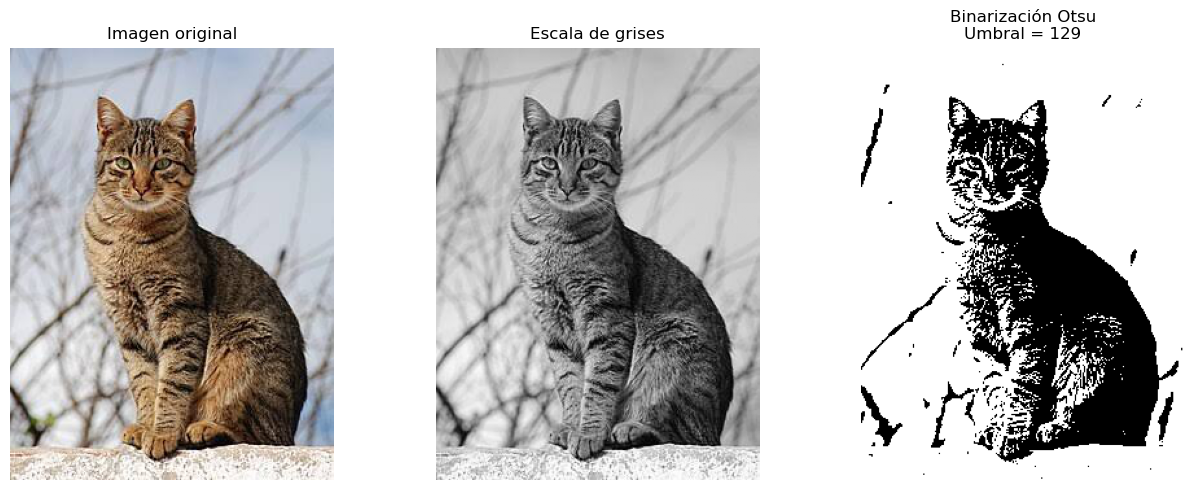

In [2]:

def binarizar_imagen(imagen_color):
    """
    Convierte una imagen a escala de grises y aplica binarización de Otsu.
    """
    gris = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2GRAY)
    umbral, binaria = cv2.threshold(
        gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return gris, binaria, umbral

imagen_p1 = cargar_imagen("problema 1.jpg")
gris_p1, binaria_p1, umbral_p1 = binarizar_imagen(imagen_p1)

fig, ejes = plt.subplots(1, 3, figsize=(13, 5))

ejes[0].imshow(bgr_a_rgb(imagen_p1))
ejes[0].set_title("Imagen original")
ejes[0].axis("off")

ejes[1].imshow(gris_p1, cmap="gray")
ejes[1].set_title("Escala de grises")
ejes[1].axis("off")

ejes[2].imshow(binaria_p1, cmap="gray")
ejes[2].set_title(f"Binarización Otsu\nUmbral = {umbral_p1:.0f}")
ejes[2].axis("off")

plt.tight_layout()
plt.show()



## Problema 2: Suma, resta y operaciones lógicas



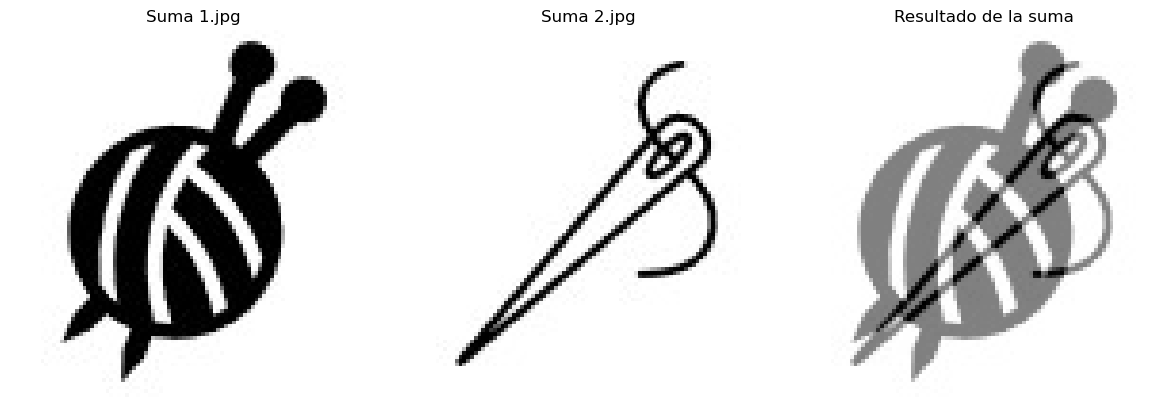

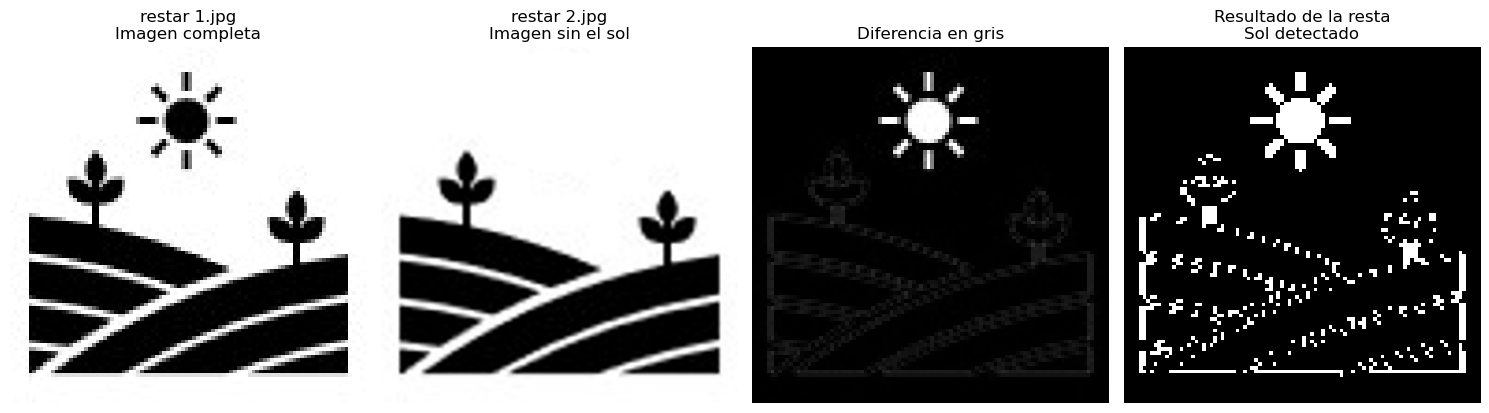

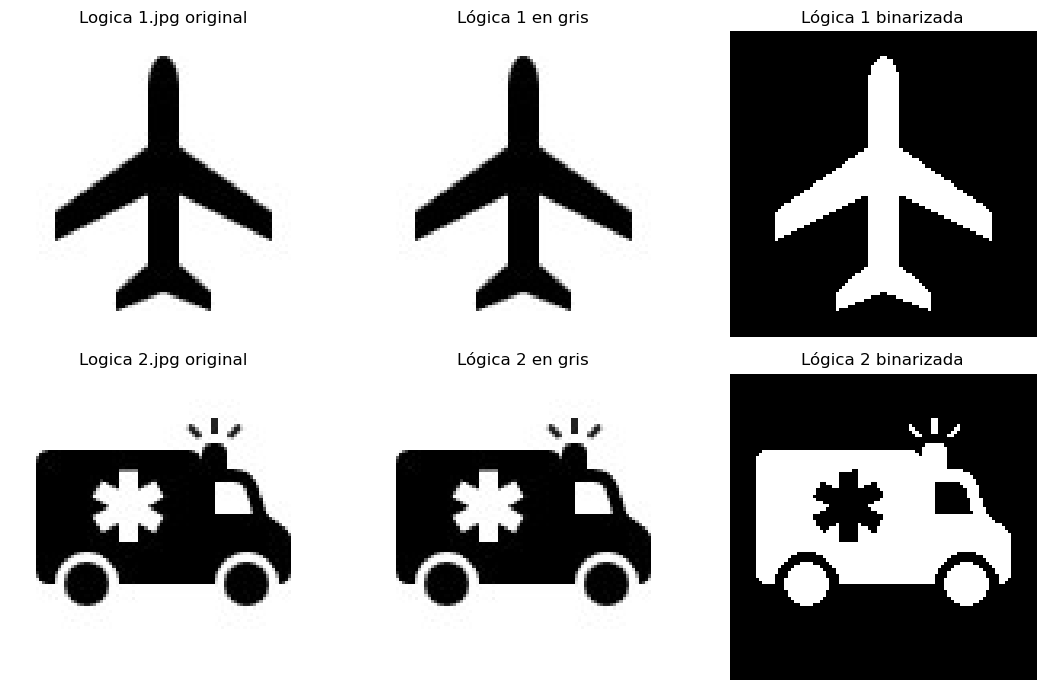

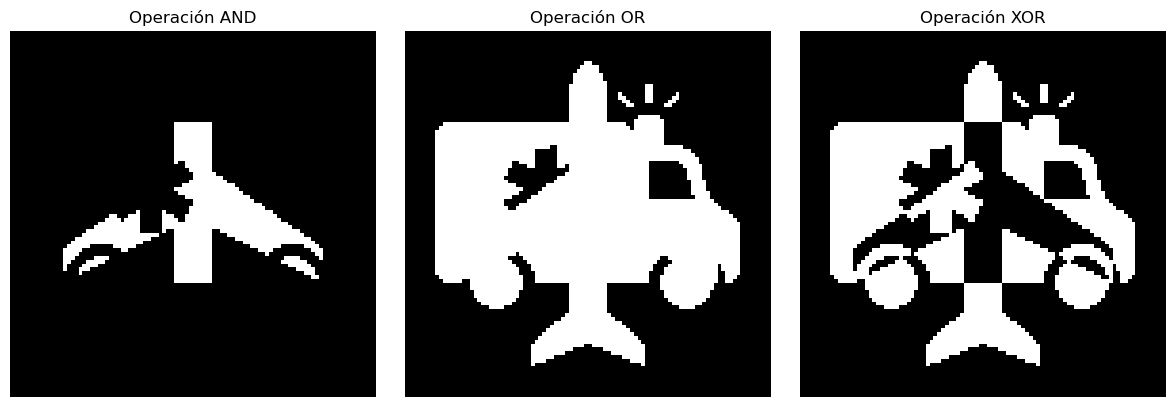

In [ ]:

# Funciones auxiliares


def cargar_imagen(ruta):
    """
    Carga una imagen a color y valida que exista.
    """
    imagen = cv2.imread(ruta)

    if imagen is None:
        raise FileNotFoundError(
            f"No se pudo encontrar o cargar la imagen: {ruta}"
        )

    return imagen


def convertir_rgb(imagen):
    """
    Convierte una imagen de BGR a RGB para mostrarla
    correctamente con Matplotlib.
    """
    return cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)


def igualar_dimensiones(imagen_1, imagen_2):
    """
    Ajusta la segunda imagen al tamaño de la primera cuando
    sus dimensiones son diferentes.
    """
    alto, ancho = imagen_1.shape[:2]

    if imagen_2.shape[:2] != (alto, ancho):
        imagen_2 = cv2.resize(
            imagen_2,
            (ancho, alto),
            interpolation=cv2.INTER_AREA
        )

    return imagen_1, imagen_2


# suma

def sumar_imagenes(imagen_1, imagen_2):
    """
    Suma dos imágenes a color.

    Se utiliza addWeighted para evitar que la suma directa
    sature demasiados píxeles en 255.
    """
    imagen_1, imagen_2 = igualar_dimensiones(
        imagen_1,
        imagen_2
    )

    resultado = cv2.addWeighted(
        imagen_1, 0.5,
        imagen_2, 0.5,
        0
    )

    return resultado


# resta

def restar_imagenes(imagen_completa, imagen_sin_objeto):
    """
    Calcula la diferencia entre una imagen completa y otra
    imagen a la que le falta un objeto.

    En este caso:
    - restar 1.jpg contiene el sol.
    - restar 2.jpg no contiene el sol.

    La diferencia absoluta permite conservar el objeto que
    aparece solamente en una de las dos imágenes.
    """
    imagen_completa, imagen_sin_objeto = igualar_dimensiones(
        imagen_completa,
        imagen_sin_objeto
    )

    # Diferencia entre las dos imágenes a color
    diferencia_color = cv2.absdiff(
        imagen_completa,
        imagen_sin_objeto
    )

    # Conversión a escala de grises
    diferencia_gris = cv2.cvtColor(
        diferencia_color,
        cv2.COLOR_BGR2GRAY
    )

    # Binarización para eliminar pequeñas diferencias
    # causadas por compresión JPEG o redimensionamiento
    _, diferencia_binaria = cv2.threshold(
        diferencia_gris,
        20,
        255,
        cv2.THRESH_BINARY
    )

    return diferencia_color, diferencia_gris, diferencia_binaria



# Preparación de imágenes para operaciones lógicas


def preparar_imagen_binaria(imagen):
    """
    Convierte una imagen a escala de grises y posteriormente
    la binariza.

    Se utiliza THRESH_BINARY_INV para representar:
    - Objeto: blanco, valor 255.
    - Fondo: negro, valor 0.
    """
    imagen_gris = cv2.cvtColor(
        imagen,
        cv2.COLOR_BGR2GRAY
    )

    _, imagen_binaria = cv2.threshold(
        imagen_gris,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    return imagen_gris, imagen_binaria


def aplicar_operaciones_logicas(imagen_1, imagen_2):
    """
    Aplica las operaciones AND, OR y XOR entre dos imágenes
    previamente convertidas a imágenes binarias.
    """
    imagen_1, imagen_2 = igualar_dimensiones(
        imagen_1,
        imagen_2
    )

    gris_1, binaria_1 = preparar_imagen_binaria(imagen_1)
    gris_2, binaria_2 = preparar_imagen_binaria(imagen_2)

    resultado_and = cv2.bitwise_and(
        binaria_1,
        binaria_2
    )

    resultado_or = cv2.bitwise_or(
        binaria_1,
        binaria_2
    )

    resultado_xor = cv2.bitwise_xor(
        binaria_1,
        binaria_2
    )

    return (
        gris_1,
        gris_2,
        binaria_1,
        binaria_2,
        resultado_and,
        resultado_or,
        resultado_xor
    )



# SUMA DE IMÁGENES


suma_1 = cargar_imagen("Suma 1.jpg")
suma_2 = cargar_imagen("Suma 2.jpg")

resultado_suma = sumar_imagenes(
    suma_1,
    suma_2
)

fig, ejes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

ejes[0].imshow(convertir_rgb(suma_1))
ejes[0].set_title("Suma 1.jpg")
ejes[0].axis("off")

ejes[1].imshow(convertir_rgb(suma_2))
ejes[1].set_title("Suma 2.jpg")
ejes[1].axis("off")

ejes[2].imshow(convertir_rgb(resultado_suma))
ejes[2].set_title("Resultado de la suma")
ejes[2].axis("off")

plt.tight_layout()
plt.show()



# RESTA DE IMÁGENES


# Imagen completa, con el sol
restar_1 = cargar_imagen("restar 1.jpg")

# Imagen sin el sol
restar_2 = cargar_imagen("restar 2.jpg")

(
    resultado_resta_color,
    resultado_resta_gris,
    resultado_resta_binaria
) = restar_imagenes(
    restar_1,
    restar_2
)

fig, ejes = plt.subplots(
    1,
    4,
    figsize=(15, 4)
)

ejes[0].imshow(convertir_rgb(restar_1))
ejes[0].set_title("restar 1.jpg\nImagen completa")
ejes[0].axis("off")

ejes[1].imshow(convertir_rgb(restar_2))
ejes[1].set_title("restar 2.jpg\nImagen sin el sol")
ejes[1].axis("off")

ejes[2].imshow(resultado_resta_gris, cmap="gray")
ejes[2].set_title("Diferencia en gris")
ejes[2].axis("off")

ejes[3].imshow(resultado_resta_binaria, cmap="gray")
ejes[3].set_title("Resultado de la resta\nSol detectado")
ejes[3].axis("off")

plt.tight_layout()
plt.show()



# OPERACIONES LÓGICAS: AND, OR Y XOR


logica_1 = cargar_imagen("Logica 1.jpg")
logica_2 = cargar_imagen("Logica 2.jpg")

(
    gris_logica_1,
    gris_logica_2,
    binaria_logica_1,
    binaria_logica_2,
    resultado_and,
    resultado_or,
    resultado_xor
) = aplicar_operaciones_logicas(
    logica_1,
    logica_2
)


# Imágenes originales y binarizadas
fig, ejes = plt.subplots(
    2,
    3,
    figsize=(11, 7)
)

ejes[0, 0].imshow(convertir_rgb(logica_1))
ejes[0, 0].set_title("Logica 1.jpg original")
ejes[0, 0].axis("off")

ejes[0, 1].imshow(gris_logica_1, cmap="gray")
ejes[0, 1].set_title("Lógica 1 en gris")
ejes[0, 1].axis("off")

ejes[0, 2].imshow(binaria_logica_1, cmap="gray")
ejes[0, 2].set_title("Lógica 1 binarizada")
ejes[0, 2].axis("off")

ejes[1, 0].imshow(convertir_rgb(logica_2))
ejes[1, 0].set_title("Logica 2.jpg original")
ejes[1, 0].axis("off")

ejes[1, 1].imshow(gris_logica_2, cmap="gray")
ejes[1, 1].set_title("Lógica 2 en gris")
ejes[1, 1].axis("off")

ejes[1, 2].imshow(binaria_logica_2, cmap="gray")
ejes[1, 2].set_title("Lógica 2 binarizada")
ejes[1, 2].axis("off")

plt.tight_layout()
plt.show()


# Resultados de las operaciones lógicas
fig, ejes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

ejes[0].imshow(resultado_and, cmap="gray")
ejes[0].set_title("Operación AND")
ejes[0].axis("off")

ejes[1].imshow(resultado_or, cmap="gray")
ejes[1].set_title("Operación OR")
ejes[1].axis("off")

ejes[2].imshow(resultado_xor, cmap="gray")
ejes[2].set_title("Operación XOR")
ejes[2].axis("off")

plt.tight_layout()
plt.show()


## Problema 3


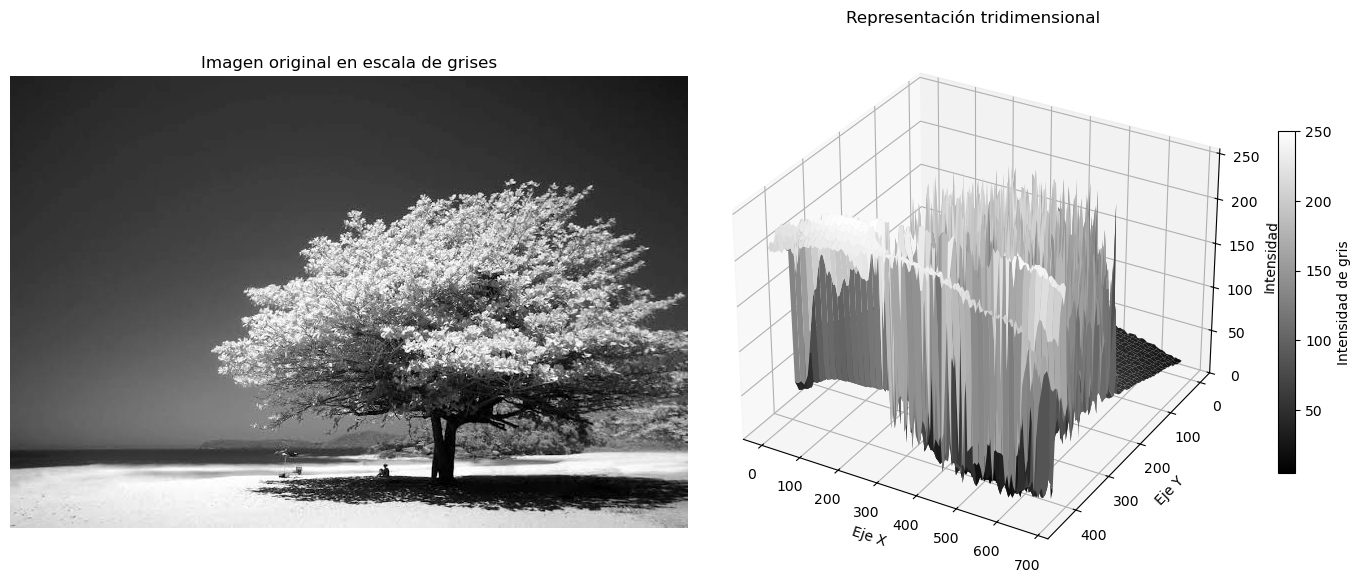

In [5]:

def mostrar_imagen_3d(imagen_color, paso=4):
    """
    Muestra una imagen en escala de grises como superficie 3D.
    """
    gris = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2GRAY)
    gris_reducida = gris[::paso, ::paso]
    alto, ancho = gris_reducida.shape

    x = np.arange(0, ancho * paso, paso)
    y = np.arange(0, alto * paso, paso)
    X, Y = np.meshgrid(x, y)
    Z = gris_reducida.astype(np.float32)

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(gris, cmap="gray")
    ax1.set_title("Imagen original en escala de grises")
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    superficie = ax2.plot_surface(
        X, Y, Z, cmap="gray", linewidth=0, antialiased=True
    )
    ax2.set_title("Representación tridimensional")
    ax2.set_xlabel("Eje X")
    ax2.set_ylabel("Eje Y")
    ax2.set_zlabel("Intensidad")
    ax2.set_zlim(0, 255)
    ax2.invert_yaxis()

    fig.colorbar(superficie, ax=ax2, shrink=0.6, label="Intensidad de gris")
    plt.tight_layout()
    plt.show()

    return gris

imagen_p3 = cargar_imagen("problema 3.jpg")
gris_p3 = mostrar_imagen_3d(imagen_p3, paso=5)

## Problema 4

Transformaciones negativa, lineal, logarítmica y exponencial

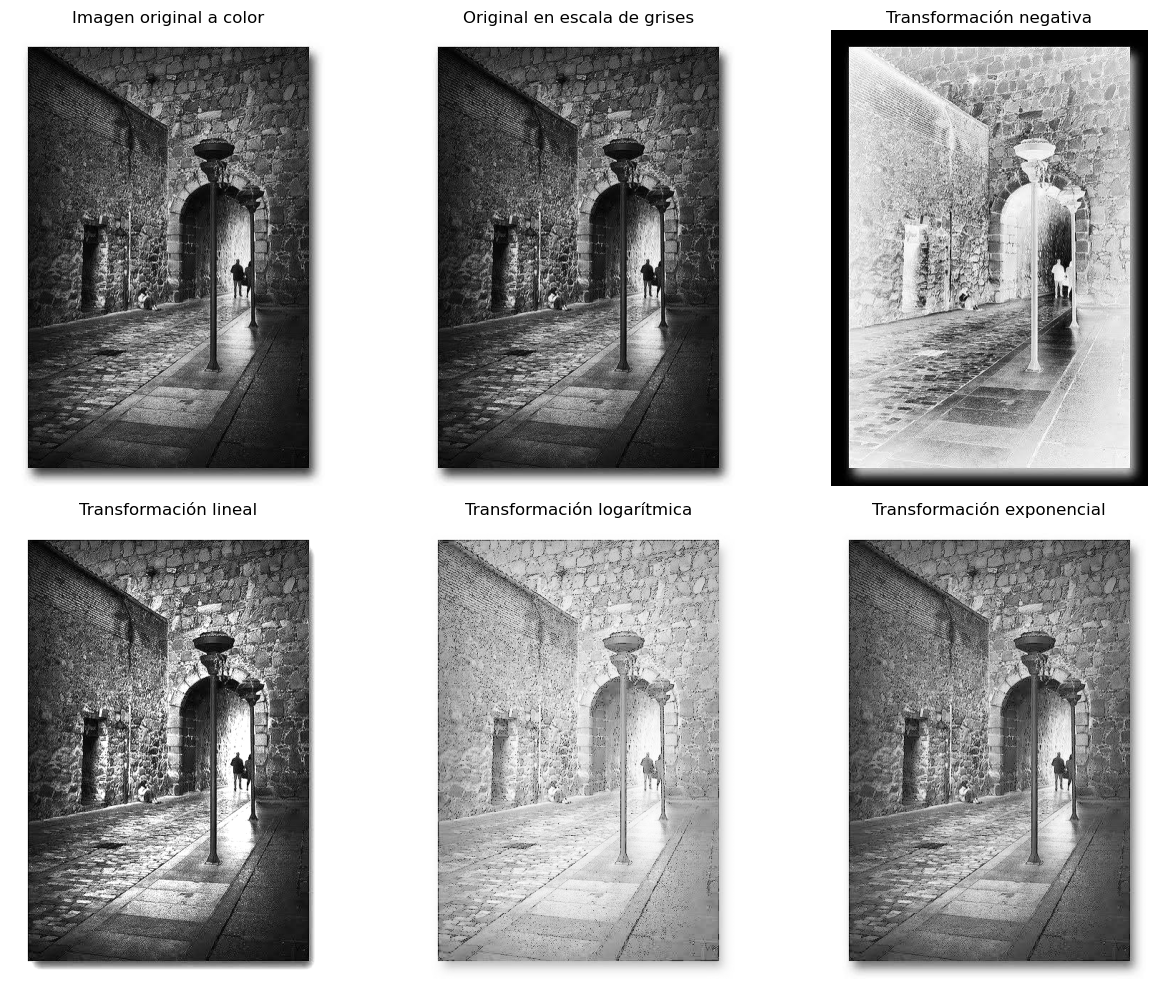

In [6]:

def transformacion_negativa(imagen_gris):
    """s = 255 - r"""
    return 255 - imagen_gris

def transformacion_lineal(imagen_gris, alpha=1.35, beta=15):
    """s = alpha * r + beta"""
    resultado = alpha * imagen_gris.astype(np.float32) + beta
    return np.clip(resultado, 0, 255).astype(np.uint8)

def transformacion_logaritmica(imagen_gris):
    """s = c * log(1 + r)"""
    imagen_float = imagen_gris.astype(np.float32)
    c = 255.0 / np.log1p(np.max(imagen_float))
    resultado = c * np.log1p(imagen_float)
    return np.clip(resultado, 0, 255).astype(np.uint8)

def transformacion_exponencial(imagen_gris, gamma=0.55, alpha=1.0):
    """s = alpha * r^gamma, con r normalizado entre 0 y 1."""
    normalizada = imagen_gris.astype(np.float32) / 255.0
    resultado = alpha * np.power(normalizada, gamma)
    return (255 * np.clip(resultado, 0, 1)).astype(np.uint8)

imagen_p4_color = cargar_imagen("problema 4.jpg")
imagen_p4_gris = cv2.cvtColor(imagen_p4_color, cv2.COLOR_BGR2GRAY)

negativa = transformacion_negativa(imagen_p4_gris)
lineal = transformacion_lineal(imagen_p4_gris, alpha=1.35, beta=15)
logaritmica = transformacion_logaritmica(imagen_p4_gris)
exponencial = transformacion_exponencial(imagen_p4_gris, gamma=0.55)

fig, ejes = plt.subplots(2, 3, figsize=(13, 10))

ejes[0, 0].imshow(bgr_a_rgb(imagen_p4_color))
ejes[0, 0].set_title("Imagen original a color")

ejes[0, 1].imshow(imagen_p4_gris, cmap="gray")
ejes[0, 1].set_title("Original en escala de grises")

ejes[0, 2].imshow(negativa, cmap="gray")
ejes[0, 2].set_title("Transformación negativa")

ejes[1, 0].imshow(lineal, cmap="gray")
ejes[1, 0].set_title("Transformación lineal")

ejes[1, 1].imshow(logaritmica, cmap="gray")
ejes[1, 1].set_title("Transformación logarítmica")

ejes[1, 2].imshow(exponencial, cmap="gray")
ejes[1, 2].set_title("Transformación exponencial")

for eje in ejes.flat:
    eje.axis("off")

plt.tight_layout()
plt.show()

## Problema 5

La función permite seleccionar dimensiones **3×3, 5×5, 7×7, 9×9 y 11×11**, y los tipos **gaussiano, Sobel, sharp, unsharp y laplaciano**.

Se da una imagen de ejemplo resultado de la función **Sharp de 7×7**.

Kernel Sharp 7x7:
[[-0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204]
 [-0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204]
 [-0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204]
 [-0.0204 -0.0204 -0.0204  1.9796 -0.0204 -0.0204 -0.0204]
 [-0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204]
 [-0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204]
 [-0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204 -0.0204]]

Suma de los elementos del kernel: 1.0000


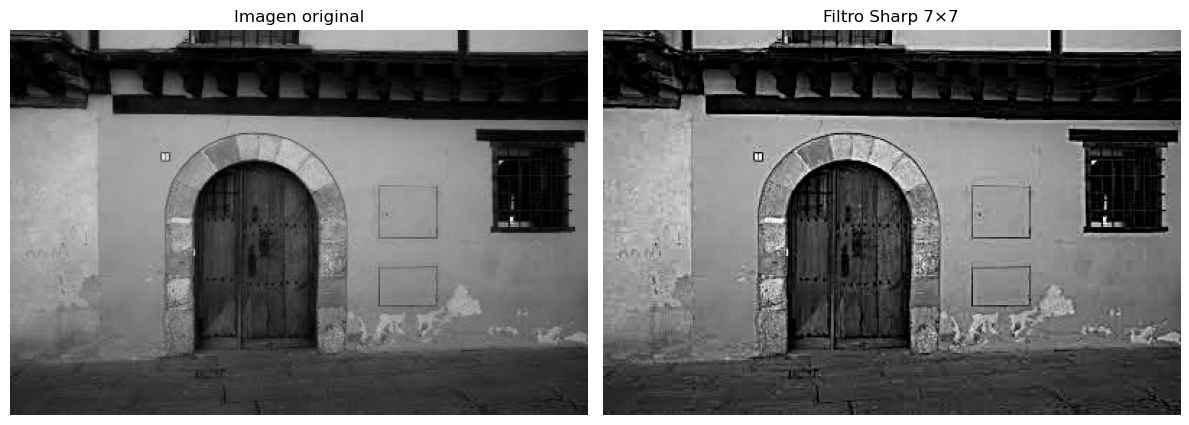

In [7]:

def construir_kernel(tipo, dimension):
    """
    Construye un kernel NumPy según el tipo y dimensión solicitados.
    """
    dimensiones_validas = {3, 5, 7, 9, 11}
    if dimension not in dimensiones_validas:
        raise ValueError(
            f"Dimensión no válida. Use una de estas: {sorted(dimensiones_validas)}"
        )

    tipo = tipo.lower()

    if tipo == "gaussiano":
        vector = cv2.getGaussianKernel(dimension, sigma=0)
        kernel = vector @ vector.T
        kernel = kernel / kernel.sum()

    elif tipo == "sobel":
        kx, ky = cv2.getDerivKernels(
            dx=1, dy=0, ksize=dimension, normalize=True
        )
        kernel = ky @ kx.T

    elif tipo == "sharp":
        kernel_promedio = np.ones((dimension, dimension), dtype=np.float32)
        kernel_promedio /= dimension ** 2
        kernel = -kernel_promedio
        centro = dimension // 2
        kernel[centro, centro] += 2.0

    elif tipo == "unsharp":
        vector = cv2.getGaussianKernel(dimension, sigma=0)
        gaussiano = vector @ vector.T
        gaussiano /= gaussiano.sum()
        kernel = -gaussiano
        centro = dimension // 2
        kernel[centro, centro] += 2.0

    elif tipo == "laplaciano":
        kx2, ky0 = cv2.getDerivKernels(
            dx=2, dy=0, ksize=dimension, normalize=True
        )
        kx0, ky2 = cv2.getDerivKernels(
            dx=0, dy=2, ksize=dimension, normalize=True
        )
        kernel = (ky0 @ kx2.T) + (ky2 @ kx0.T)

    else:
        raise ValueError(
            "Tipo no válido. Use: gaussiano, sobel, sharp, unsharp o laplaciano."
        )

    return kernel.astype(np.float32)

def aplicar_filtro_convolucion(imagen, tipo, dimension):
    """
    Construye el kernel y aplica convolución a una imagen a color.
    """
    kernel = construir_kernel(tipo, dimension)
    filtrada = cv2.filter2D(
        imagen,
        ddepth=-1,
        kernel=kernel,
        borderType=cv2.BORDER_REFLECT
    )
    return filtrada, kernel

imagen_p5 = cargar_imagen("problema 5.jpg")

imagen_filtrada_p5, kernel_sharp_7 = aplicar_filtro_convolucion(
    imagen_p5, tipo="sharp", dimension=7
)

print("Kernel Sharp 7x7:")
print(np.round(kernel_sharp_7, 4))
print(f"\nSuma de los elementos del kernel: {kernel_sharp_7.sum():.4f}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(bgr_a_rgb(imagen_p5))
ejes[0].set_title("Imagen original")
ejes[0].axis("off")

ejes[1].imshow(bgr_a_rgb(imagen_filtrada_p5))
ejes[1].set_title("Filtro Sharp 7×7")
ejes[1].axis("off")

plt.tight_layout()
plt.show()


## Problema 6: Kernel laplaciano y comparación con Canny

El **kernel laplaciano** es un operador de segunda derivada que identifica cambios rápidos de intensidad en una imagen. Su respuesta es alta alrededor de transiciones bruscas, por lo que se utiliza para resaltar bordes y detalles finos. Normalmente se aplica sobre una imagen en escala de grises y, debido a que las segundas derivadas también amplifican el ruido, suele combinarse con un suavizado previo. El resultado puede contener bordes positivos y negativos, por lo que frecuentemente se convierte a valor absoluto o se combina con la imagen original para mejorar su nitidez.

El algoritmo de **Canny** es un procedimiento de detección de bordes compuesto por varias etapas: suavizado gaussiano, cálculo del gradiente, supresión de máximos no locales y umbralización por histéresis. A diferencia del laplaciano, Canny busca producir bordes más delgados, continuos y menos sensibles al ruido. El laplaciano es más directo y sencillo, pero puede generar bordes dobles o respuestas ruidosas; Canny requiere configurar dos umbrales, aunque normalmente ofrece una detección de contornos más limpia y controlada.
